In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('cleaned_abstracts.csv')
df

,abstracts
0,Indoor photovoltaics are promising to enable s...
1,The energy loss in perovskite solar cells (PSC...
2,Organic–inorganic hybrid perovskite solar cell...
3,Heavily Br-doped PSCs have a segregation-free ...
4,A novel biphenyl fumaronitrile as an acceptor ...
...,...
3366,The stability of encapsulated planar-structure...
3367,Perovskite solar cells (PSCs) with mesoporous ...
3368,"In recent years, there has been an unprecedent..."
3369,Wide bandgap (Eg) perovskite solar cells (PSCs...


In [7]:
import pandas as pd

# Load your CSV
df = pd.read_csv('cleaned_abstracts.csv')

# Drop NaN or empty abstracts BEFORE embedding
df_clean = df.dropna().copy()
df_clean = df_clean[df_clean['abstracts'].str.strip().astype(bool)].reset_index(drop=True)

# Now df_clean.shape[0] should match embeddings.shape[0]
print(df_clean.shape)

(3371, 1)


In [9]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 20.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 21.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 21.9 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 21.8 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 19.4 MB/s eta 0:00:00m eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 21.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 21.8 MB/s eta 0:00:0031m22.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 20.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 22.0 MB/s eta 0:00:00MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 22.0 MB/s eta 0:00:00m eta 0:00:010:01:

In [11]:
import torch 

if torch.cuda.is_available():
    print("GPU is available")

In [13]:
df.shape

(3371, 1)

In [14]:
# embedding = np.load("stella_encoded_data.npy")
embedding = np.load("stella_embeddings.npy")

embedding.shape

(3371, 1024)

In [15]:
embedding[0]

array([-0.22475423,  0.34246272, -0.0339629 , ...,  0.07205345,
       -0.02839921, -0.11450056], dtype=float32)

In [24]:
# remember that the best so far was 55 
reducer = umap.UMAP(n_components=55,random_state=42)
reduced_data  = reducer.fit_transform(embedding)

In [25]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [22]:
embedding.shape

(3371, 1024)

In [23]:
reduced_data.shape

(3371, 55)

In [33]:
# remember that the best so far was 55 (For Agglomerative Clustering)
pca = PCA(n_components=55,random_state=42)
X_reduced = pca.fit_transform(embedding)

In [38]:
embedding.shape

(3371, 1024)

In [39]:
X_reduced.shape

(3371, 55)

In [34]:
linkage_matrix = linkage(X_reduced, method='ward')

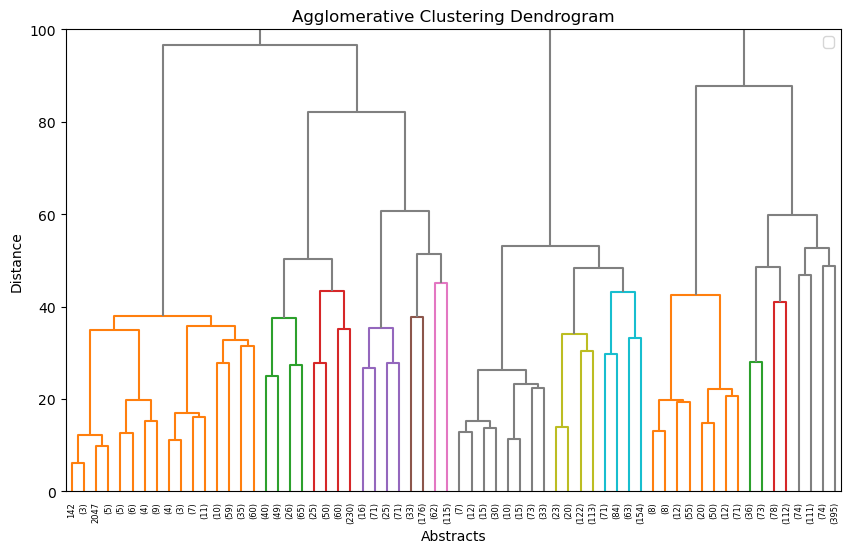

In [35]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Agglomerative clustering
clusterer = AgglomerativeClustering(n_clusters=15, linkage='ward')

# Create linkage matrix directly from the data (Ward method)
linkage_matrix = linkage(X_reduced, method='ward')

# Calculate correct threshold for 15 clusters
threshold_index = len(X_reduced) - 15 - 1
distance_threshold = linkage_matrix[threshold_index, 2]

plt.figure(figsize=(10, 6))

# above_threshold_color='gray' to show merged clusters
dendrogram(linkage_matrix, 
           truncate_mode='level', 
           p=5, 
           color_threshold=distance_threshold, 
           above_threshold_color='gray')        

plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Abstracts")
plt.ylabel("Distance")
plt.legend()  
plt.ylim(0, 100)
plt.show()

In [37]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA
from umap import UMAP
import plotly.graph_objects as go

# ============================================================
# CONFIG
# ============================================================

INPUT_FILE = "cleaned_abstracts.csv"
N_CLUSTERS = 15
DENDROGRAM_LEVELS = 5
n_components = 55  


STOPWORDS = {
    'a','an','the','of','for','with','on','at','by','from','to','i',
    'and','or','but','as','is','are','was','were','be','been','being',
    'have','has','had','can','will','would','could','should',
    'this','that','these','those','which','their','our','its',
    'using','used','use','based','showed','shown','show','we'
}

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE)
abstracts = df["abstracts"].tolist()
n_abstracts = len(abstracts)

# ============================================================
# 2. AGGLOMERATIVE CLUSTERING
# ============================================================

vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(abstracts)

pca = PCA(n_components=55)
X_reduced = pca.fit_transform(embedding)

clusterer = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward"
)
cluster_labels = clusterer.fit_predict(X_reduced)

linkage_matrix = linkage(X_reduced, method="ward")

threshold_index = len(X_reduced) - N_CLUSTERS - 1
distance_threshold = linkage_matrix[threshold_index, 2]

# ============================================================
# 3. BUILD FULL TREE
# ============================================================

node_members = {i: [i] for i in range(n_abstracts)}

for merge_idx, (l, r, _, _) in enumerate(linkage_matrix):
    node_id = n_abstracts + merge_idx
    node_members[node_id] = node_members[int(l)] + node_members[int(r)]

# Parent–child relations
merge_children = {}
merge_parent = {}

for merge_idx, (l, r, _, _) in enumerate(linkage_matrix):
    merge_children[merge_idx] = (int(l), int(r))
    if l >= n_abstracts:
        merge_parent[l - n_abstracts] = merge_idx
    if r >= n_abstracts:
        merge_parent[r - n_abstracts] = merge_idx

# ============================================================
# 4. DENDROGRAM
# ============================================================

dend = dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=DENDROGRAM_LEVELS,
    color_threshold=distance_threshold,
    no_plot=True
)

icoord = dend["icoord"]
dcoord = dend["dcoord"]

# ============================================================
# 5. SIBLING-AWARE c-TF-IDF
# ============================================================

def extract_keywords(node_indices, sibling_indices_list):
    node_doc = " ".join(abstracts[i] for i in node_indices)

    if not sibling_indices_list:
        tfidf = TfidfVectorizer(
            stop_words=list(STOPWORDS),
            ngram_range=(1, 3),
            max_features=500
        )
        scores = tfidf.fit_transform([node_doc]).toarray()[0]
        terms = tfidf.get_feature_names_out()
        top = scores.argsort()[-10:][::-1]
        return [terms[i] for i in top if scores[i] > 0]

    sibling_docs = [
        " ".join(abstracts[i] for i in sib)
        for sib in sibling_indices_list
    ]

    vectorizer = CountVectorizer(
        stop_words=list(STOPWORDS),
        ngram_range=(1, 3),
        max_features=1500
    )

    mat = vectorizer.fit_transform([node_doc] + sibling_docs)
    terms = vectorizer.get_feature_names_out()

    node_tf = mat[0].toarray().flatten()
    sib_tf = mat[1:].toarray()

    node_freq = node_tf / (node_tf.sum() + 1)
    sib_freq = sib_tf.mean(axis=0) / (sib_tf.sum(axis=1).mean() + 1)

    score = node_freq - sib_freq
    top = score.argsort()[-20:][::-1]

    return [
        terms[i] for i in top
        if score[i] > 0 and node_tf[i] >= 2
    ]

# ============================================================
# 6. UNIQUE LABEL GENERATION
# ============================================================

def make_label(keywords, used):
    if not keywords:
        return "General Research"

    phrases = [k for k in keywords if " " in k]
    singles = [k for k in keywords if " " not in k]

    def cap(w): return w.title()

    for p in phrases:
        label = " ".join(cap(w) for w in p.split())
        if label not in used:
            return label

    for i in range(min(5, len(singles)-1)):
        label = f"{cap(singles[i])} {cap(singles[i+1])}"
        if label not in used:
            return label

    base = cap(singles[0])
    k = 1
    while f"{base} {k}" in used:
        k += 1
    return f"{base} {k}"

# ============================================================
# 7. MAP VISIBLE NODES + UNIQUE LABELS + CLUSTER INFO
# ============================================================

visible_nodes = []
used_labels = set()

for xs, ys in zip(icoord, dcoord):
    h = max(ys)
    x = (xs[1] + xs[2]) / 2

    candidates = []
    for i, (_, _, dist, _) in enumerate(linkage_matrix):
        if abs(dist - h) < 1e-3:
            node_id = n_abstracts + i
            candidates.append((node_id, node_members[node_id]))

    if not candidates:
        continue

    node_id, members = max(candidates, key=lambda x: len(x[1]))

    siblings = []
    merge_idx = node_id - n_abstracts
    if merge_idx in merge_parent:
        p = merge_parent[merge_idx]
        l, r = merge_children[p]
        for s in (l, r):
            if s != node_id and s in node_members:
                siblings.append(node_members[s])

    keywords = extract_keywords(members, siblings)
    label = make_label(keywords, used_labels)
    used_labels.add(label)

    visible_nodes.append(dict(
        x=x,
        y=h,
        label=label,
        keywords=keywords,
        n=len(members),
        clusters=sorted(set(cluster_labels[i] for i in members)),
        samples=[abstracts[i][:200] for i in members[:5]]
    ))

# ============================================================
# 8. PLOTLY DENDROGRAM WITH CLUSTER AND ABSTRACT INFO
# ============================================================

fig = go.Figure()

for x, y in zip(icoord, dcoord):
    fig.add_trace(go.Scatter(
        x=x, y=y, mode="lines",
        line=dict(color="gray", width=1),
        hoverinfo="skip",
        showlegend=False
    ))

for n in visible_nodes:
    fig.add_trace(go.Scatter(
        x=[n["x"]], y=[n["y"]],
        mode="markers+text",
        marker=dict(size=7),
        text=n["label"],
        textposition="top center",
        hovertext=(
            f"<b>{n['label']}</b><br>"
            f"Number of Abstracts: {n['n']}<br>"
            f"Cluster(s): {n['clusters']}<br><br>"
            f"<b>All c-TF-IDF keywords:</b><br>"
            + ", ".join(n["keywords"]) +
            "<br><br>" +
            "<br>".join(n["samples"])
        ),
        hoverinfo="text",
        showlegend=False
    ))

fig.update_layout(
    title="Agglomerative Dendrogram with Unique Automatic Labels",
    xaxis=dict(showticklabels=False),
    yaxis=dict(title="Distance"),
    width=2200,
    height=1100
)

fig.write_html("interactive_dendrogram_full keywords.html", auto_open=True)